## Лабораторная работа № 2 
## Машинное обучение на больших данных с использованием фреймворка Apache Spark и библиотеки SparkML

### Часть 2

В данной части работы рассмотрены:
* подготовка признаков для рашения задачи **градиентного бустинга** на деревьях решений;
* создание и обучение модели градиентного бустинга;
* оценка качества модели.

#### Запуск `Spark`-сессии

Подключаем необходимые библиотеки.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.ml.feature import VectorAssembler, StringIndexer, Binarizer, Bucketizer
from pyspark.ml.functions import vector_to_array
from pyspark.ml.classification import GBTClassifier, GBTClassificationModel
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, CrossValidatorModel, ParamGridBuilder
from pyspark.ml import Pipeline
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.sql import Window
from pyspark.sql.functions import col

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    # Получаем имя пользователя
    # Получаем имя пользователя
    user_name = os.getenv("USER")
    
    conf = SparkConf()
    conf.setAppName("lab 1 Test")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    conf.set("spark.executor.memory", "12g")
    conf.set("spark.executor.cores", "6")
    conf.set("spark.executor.instances", "1")
    conf.set("spark.driver.memory", "4g")
    conf.set("spark.driver.cores", "1")

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

#### Загрузка датасета

In [5]:
df = spark.read.parquet("sobd_lab1_table_parquet")

Выведем прочитанную таблицу на экран.

In [6]:
df.show()

+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+------------+--------------+
|        id|               title|             authors|           publisher|      published_date|          categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       user_id|        profile_name|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|       authors_array|    categories_array|author_count|category_count|
+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+-----------

Вспомним схему данных.

In [7]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- published_date: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_summary: string (nullable = true)
 |-- review_helpfulness: string (nullable = true)
 |-- review_time: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- profile_name: string (nullable = true)
 |-- helpfulness_numerator: integer (nullable = true)
 |-- helpfulness_denominator: integer (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)
 |-- authors_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- categories_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- author_count: integer (nullable = true)
 |-- category_count: integer (nullable = true)



Вычислим количество строк в датафрейме.

In [8]:
df.count()

221989

#### Постановка задачи

Для датасета, заданного представленными колонками, требуется построить модель градиентного бустинга на деревьях решений для оценки факта того, является ли отзыв полезным, по всем остальным признакам.

Для оценки качества обучения следует использовать метрики Precision и Recall. Оценить максимально возможное значение точности при полноте не менее 60%.

#### Подготовка и кодирование признаков

Для корректной работы трансформеров и модели преобразуем столбец `helpfulness_ratio` к типу `DoubleType`, а столбец `is_helpful` к типу `IntegerType`.

In [9]:
# Создаем бинарные признаки
from pyspark.sql.functions import when

# Бинаризация helpfulness_ratio
df = df.withColumn("is_helpful", 
    when(col("helpfulness_ratio") > 0.5, 1).otherwise(0))

# Бинаризация author_count
df = df.withColumn("has_multiple_authors",
    when(col("author_count") > 1, 1).otherwise(0))

# Бинаризация category_count
df = df.withColumn("has_multiple_categories",
    when(col("category_count") > 2, 1).otherwise(0))

# Бинаризация review_time (используем реалистичный порог)
# Найдем 75-й перцентиль для review_time
review_time_threshold = df.approxQuantile("review_time", [0.75], 0.01)[0]
df = df.withColumn("is_recent_review",
    when(col("review_time") > review_time_threshold, 1).otherwise(0))

print("Анализ потенциальной утечки данных:")

# Проверяем корреляцию helpfulness_ratio с целевой переменной
leakage_check = df.select(
    F.corr("helpfulness_ratio", "is_helpful").alias("corr_helpfulness_ratio"),
    F.corr("helpfulness_numerator", "is_helpful").alias("corr_numerator"),
    F.corr("helpfulness_denominator", "is_helpful").alias("corr_denominator")
).collect()[0]

print(f"Корреляция helpfulness_ratio с целевой: {leakage_check['corr_helpfulness_ratio']:.4f}")
print(f"Корреляция numerator с целевой: {leakage_check['corr_numerator']:.4f}")
print(f"Корреляция denominator с целевой: {leakage_check['corr_denominator']:.4f}")

Анализ потенциальной утечки данных:
Корреляция helpfulness_ratio с целевой: 0.9593
Корреляция numerator с целевой: 0.2987
Корреляция denominator с целевой: 0.2595


In [10]:
df = df.withColumn("helpfulness_ratio", col("helpfulness_ratio").cast(DoubleType()))
df = df.withColumn("is_helpful", col("is_helpful").cast(IntegerType()))

df = df.withColumn("review_text_length", F.length("review_text"))
df = df.withColumn("review_summary_length", F.length("review_summary"))
df = df.withColumn("title_length", F.length("title"))

# Извлекаем год и месяц из review_time
df = df.withColumn("review_year", F.year(F.from_unixtime("review_time")))
df = df.withColumn("review_month", F.month(F.from_unixtime("review_time")))

In [11]:
df = df.withColumn("publisher_type", 
                   F.when(F.col("publisher").isNull() | 
                          (F.col("publisher") == "Unknown Publisher"), "unknown")
                    .when(F.col("publisher").isin(["Penguin", "Vintage", "Harper", "Random House", "Oxford"]), "major")
                    .otherwise("other"))

In [12]:
df = df.withColumn("main_category", 
                   F.when(F.lower(F.col("categories")).contains("fiction"), "fiction")
                    .when(F.lower(F.col("categories")).contains("non") | 
                          F.lower(F.col("categories")).contains("biography"), "non_fiction")
                    .when(F.lower(F.col("categories")).contains("children") | 
                          F.lower(F.col("categories")).contains("kids"), "children")
                    .otherwise("other"))

Выполним **стратифицированное** разделение датасета на обучающую и тестовую выборки.

In [13]:
def stratified_train_test_split(data: DataFrame, 
                                label_col: str,
                                ratio: float) -> tuple[DataFrame, DataFrame]:
    """
    Разделяет DataFrame на тренировочный и тестовый наборы с учетом стратификации.

    Args:
        data: Исходный DataFrame.
        label_col: Название столбца с меткой.
        ratio: Пропорция разделения данных.

    Returns:
        tuple[DataFrame, DataFrame]: Кортеж из тренировочного и тестового DataFrame.
    """
    # Проверяем корректность доли разделения
    assert (isinstance(ratio, float) and (0.0 <= ratio <= 1.0))
    
    # Формируем разделение для положительных и отрицательных объектов раздельно
    train_df_pos, test_df_pos = (data
                                 .filter(F.col(label_col) == 1)
                                 .randomSplit([ratio, 1 - ratio]))
    train_df_neg, test_df_neg = (data
                                 .filter(F.col(label_col) == 0)
                                 .randomSplit([ratio, 1 - ratio]))
    
    # Объединяем датафреймы
    return (train_df_pos.union(train_df_neg),
            test_df_pos.union(test_df_neg))

In [14]:
# Используем случайное разделение вместо стратифицированного
# чтобы избежать потенциальных проблем
train_ratio = 0.8
train_df, test_df = df.randomSplit([train_ratio, 1 - train_ratio], seed=42)

print(f"Размер обучающей выборки: {train_df.count()}")
print(f"Размер тестовой выборки: {test_df.count()}")

# Проверяем баланс в разделенных данных
print("\nБаланс классов в обучающей выборке:")
train_df.groupBy("is_helpful").count().show()

print("Баланс классов в тестовой выборке:")
test_df.groupBy("is_helpful").count().show()

Размер обучающей выборки: 177845
Размер тестовой выборки: 44144

Баланс классов в обучающей выборке:
+----------+------+
|is_helpful| count|
+----------+------+
|         1|130604|
|         0| 47241|
+----------+------+

Баланс классов в тестовой выборке:
+----------+-----+
|is_helpful|count|
+----------+-----+
|         1|32474|
|         0|11670|
+----------+-----+



Закешируем сформированные датафреймы и проверим их объем.

In [15]:
train_df = train_df.cache()
test_df = test_df.cache()

print(f"Train dataset size: {train_df.count()}")
print(f"Test  dataset size: {test_df.count()}")

Train dataset size: 177845
Test  dataset size: 44144


In [16]:
train_df.groupBy("is_helpful").count().show()

+----------+------+
|is_helpful| count|
+----------+------+
|         1|130604|
|         0| 47241|
+----------+------+



Выполним балансировку датасета с помощью `oversampling`. 

In [17]:
def oversample(data: DataFrame, column: str) -> DataFrame:
    """
    Выполняет oversampling положительных классов в DataFrame.

    Args:
        data: Исходный DataFrame.
        column: Название столбца с меткой.

    Returns:
        DataFrame: Датафрейм с выполненным oversampling.
    """
    # Разделим датафрейм на положительные и отрицательные классы
    pos = data.filter(F.col(column) == 1.0)
    neg = data.filter(F.col(column) == 0.0)

    # Получим количество записей в каждом классе
    total_pos = pos.count()
    total_neg = neg.count()

    # Если количество положительных классов меньше отрицательных,
    # выполним oversampling
    if total_pos < total_neg:
        # Вычислим количество необходимых дубликатов
        num_duplicates = total_neg - total_pos

        # Дублируем положительные записи
        oversampled_pos = pos.withColumn(
            "dummy",
            F.explode(
                F.array_repeat(F.lit(1),
                               num_duplicates // total_pos + 1)
            )
        ).drop("dummy")

        # Объединим дублированные положительные записи с отрицательными
        balanced_df = neg.union(oversampled_pos)
    else:
        balanced_df = data

    return balanced_df

In [18]:
train_df = oversample(train_df, column="is_helpful")

Проверим баланс классов в получившемся датасете.

In [19]:
train_df.groupBy("is_helpful").count().show()

# Проверяем баланс классов после oversampling
print("Баланс классов после oversampling:")
train_balance = train_df.groupBy("is_helpful").count().collect()
for row in train_balance:
    print(f"Класс {row['is_helpful']}: {row['count']} записей "
          f"({row['count']/train_df.count()*100:.1f}%)")

# Если дисбаланс все еще большой, можно настроить oversampling

+----------+------+
|is_helpful| count|
+----------+------+
|         1|130604|
|         0| 47241|
+----------+------+

Баланс классов после oversampling:
Класс 1: 130604 записей (73.4%)
Класс 0: 47241 записей (26.6%)


Остальные признаки сгруппируем по их типу:

* **Категориальные** признаки закодируем с помощью `label encoding`.
* **Бинарные** признаки представлены значениями `true` / `false`, которые могут быть интерпретированы как единица и нуль. Поэтому, в кодировании не нуждаются.
* **Количественные** признаки для древовидных моделей в кодировании не нуждаются.

In [20]:
# Убираем ВСЕ признаки, связанные с helpfulness - это утечка данных!
categorical_features = ["publisher_type", "main_category"]
binary_features = [
    "has_multiple_authors", 
    "has_multiple_categories", 
    "is_recent_review"
]
numeric_features = [
    "review_time", 
    "author_count", 
    "category_count", 
    "review_score"  # Добавляем review_score как числовой признак
]

print(f"Категориальные: {categorical_features}")
print(f"Бинарные: {binary_features}")
print(f"Числовые: {numeric_features}")

Категориальные: ['publisher_type', 'main_category']
Бинарные: ['has_multiple_authors', 'has_multiple_categories', 'is_recent_review']
Числовые: ['review_time', 'author_count', 'category_count', 'review_score']


In [21]:
# Добавляем новые признаки в списки
numeric_features.extend(["review_text_length", "review_summary_length", "title_length"])

# Проверяем корреляцию новых признаков с целевой переменной
new_features_check = df.select(
    F.corr("review_score", "is_helpful").alias("corr_review_score"),
    F.corr("review_text_length", "is_helpful").alias("corr_text_length"),
    F.corr("author_count", "is_helpful").alias("corr_author_count"),
    F.corr("category_count", "is_helpful").alias("corr_category_count")
).collect()[0]

print("\nКорреляция новых признаков с целевой переменной:")
print(f"review_score: {new_features_check['corr_review_score']:.4f}")
print(f"review_text_length: {new_features_check['corr_text_length']:.4f}")
print(f"author_count: {new_features_check['corr_author_count']:.4f}")
print(f"category_count: {new_features_check['corr_category_count']:.4f}")


Корреляция новых признаков с целевой переменной:
review_score: 0.1344
review_text_length: 0.2213
author_count: 0.0004
category_count: -0.0013


Создадим конвейер обработки данных, включающий модель градиентного бустинга на деревьях решений.

In [22]:
def create_pipeline(categorical_features: list[str], numeric_features: list[str], 
                    binary_features: list[str], label_col: str, max_iter: int) -> Pipeline:
    
    # Для категориальных признаков с большим количеством значений используем StringIndexer с minFrequency
    string_indexer = StringIndexer(inputCols=categorical_features,
                                   outputCols=[f"{feature}_index" for feature in categorical_features],
                                   handleInvalid="keep",
                                   stringOrderType="frequencyDesc")
    
    # Объединяем все признаки
    all_features = [f"{feature}_index" for feature in categorical_features] + binary_features + numeric_features
    
    vector_assembler = VectorAssembler(
        inputCols=all_features,
        outputCol="features"
    )

    # Увеличиваем maxBins и упрощаем модель
    gbt_classifier = GBTClassifier(featuresCol="features",
                                   labelCol=label_col,
                                   predictionCol="prediction",
                                   maxIter=max_iter,
                                   maxBins=100,  # Увеличиваем для обработки категориальных признаков
                                   maxDepth=4,
                                   stepSize=0.1,
                                   seed=42)

    pipeline = Pipeline(stages=[
        string_indexer, vector_assembler, gbt_classifier
    ])

    return pipeline

In [23]:
pipeline = create_pipeline(categorical_features=categorical_features,
                           numeric_features=numeric_features,
                           binary_features=binary_features,
                           label_col="is_helpful",
                           max_iter=10)  # Уменьшаем количество итераций

#### Обучение модели

Выполним **подбор гиперпараметров** модели линейной регрессии с помощью кросс-валидации на сетке.

Создаем сетку параметров для кросс-валидации, получив объект `GBTClassifier` из конвейера.

In [24]:
param_grid = ParamGridBuilder() \
    .addGrid(pipeline.getStages()[-1].maxDepth, [2, 3]) \
    .addGrid(pipeline.getStages()[-1].maxIter, [8, 10]) \
    .addGrid(pipeline.getStages()[-1].stepSize, [0.05, 0.1]) \
    .build()

Создаем экземпляр `BinaryClassificationEvaluator` для оценки модели.

In [25]:
cv_evaluator = BinaryClassificationEvaluator(labelCol="is_helpful")

Создаем объект `CrossValidator`.

In [26]:
cross_validator = CrossValidator(estimator=pipeline,
                                 estimatorParamMaps=param_grid,
                                 evaluator=cv_evaluator,
                                 numFolds=5)

Обучаем модель конвейера с использованием кросс-валидации.

In [27]:
cv_model = cross_validator.fit(train_df)

Выведем параметры **лучшей** модели, определенной в ходе кросс-валидации.

In [28]:
def get_best_model_params(cv_model: CrossValidatorModel) -> dict[str, float]:
    """
    Получает параметры лучшей модели из объекта CrossValidatorModel.

    Args:
        cv_model: Объект CrossValidatorModel, содержащий лучшую модель.

    Returns:
        Dict[str, float]: Параметры лучшей модели.
    """
    best_model = cv_model.bestModel
    best_params = {
        "maxDepth": best_model.stages[-1].getMaxDepth(),
        "stepSize": best_model.stages[-1].getStepSize(),
        "maxIter": best_model.stages[-1].getMaxIter()
    }
    return best_params

In [29]:
for key, value in get_best_model_params(cv_model=cv_model).items():
    print(f"{key}: {value}")

maxDepth: 3
stepSize: 0.1
maxIter: 10


#### Анализ обученной модели

Рассчитаем метрики на тестовом датасете.

In [30]:
# Получаем датасет предсказаний
test_df_predictions = cv_model.transform(test_df)

# Извлекаем список колонок, устанавливаем цену на последнее место
right_columns_order = test_df_predictions.columns
right_columns_order.remove("is_helpful")
right_columns_order.append("is_helpful")

# Изменяем последовательность колонок и выводим датафрейм
test_df_predictions = test_df_predictions.select(*right_columns_order)
test_df_predictions.show()

+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+------------+--------------+--------------------+-----------------------+----------------+------------------+---------------------+------------+-----------+------------+--------------+-------------+--------------------+-------------------+--------------------+--------------------+--------------------+----------+----------+
|        id|               title|             authors|           publisher|      published_date|          categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       user_id|        profile_name|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|       authors_array|    

In [31]:
def evaluate_model(data: DataFrame, label_col: str) -> dict[str, float]:
    """
    Оценивает модель с использованием метрик точности, полноты и F1-score.
    Добавляет анализ матрицы ошибок.
    """
    # Вычисляем TP, FP, FN, TN
    tp = data.filter((F.col(label_col) == 1) & (F.col("prediction") == 1)).count()
    fp = data.filter((F.col(label_col) == 0) & (F.col("prediction") == 1)).count()
    fn = data.filter((F.col(label_col) == 1) & (F.col("prediction") == 0)).count()
    tn = data.filter((F.col(label_col) == 0) & (F.col("prediction") == 0)).count()

    # Вычисляем метрики
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0 else 0)
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

    # Выводим матрицу ошибок
    print("Матрица ошибок:")
    print(f"TP: {tp}, FP: {fp}")
    print(f"FN: {fn}, TN: {tn}")
    print(f"Всего записей: {data.count()}")

    # Возвращаем словарь с метриками
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

In [32]:
def evaluate_with_different_thresholds(predictions: DataFrame, label_col: str):
    """Оценка модели с разными порогами классификации"""
    print("\nОценка с разными порогами классификации:")
    print("Threshold | Precision | Recall   | F1       | Accuracy")
    print("-" * 55)
    
    for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
        threshold_predictions = predictions.withColumn(
            "prediction", 
            when(vector_to_array(F.col("probability")).getItem(1) > threshold, 1).otherwise(0)
        )
        
        metrics = evaluate_model(threshold_predictions, label_col)
        print(f"{threshold:8.2f} | {metrics['precision']:8.4f} | {metrics['recall']:8.4f} | "
              f"{metrics['f1']:8.4f} | {metrics['accuracy']:8.4f}")

# Применяем анализ порогов
evaluate_with_different_thresholds(test_df_predictions, "is_helpful")


Оценка с разными порогами классификации:
Threshold | Precision | Recall   | F1       | Accuracy
-------------------------------------------------------
Матрица ошибок:
TP: 31969, FP: 8782
FN: 505, TN: 2888
Всего записей: 44144
    0.30 |   0.7845 |   0.9844 |   0.8732 |   0.7896
Матрица ошибок:
TP: 31092, FP: 7342
FN: 1382, TN: 4328
Всего записей: 44144
    0.40 |   0.8090 |   0.9574 |   0.8770 |   0.8024
Матрица ошибок:
TP: 30665, FP: 6914
FN: 1809, TN: 4756
Всего записей: 44144
    0.50 |   0.8160 |   0.9443 |   0.8755 |   0.8024
Матрица ошибок:
TP: 29431, FP: 5718
FN: 3043, TN: 5952
Всего записей: 44144
    0.60 |   0.8373 |   0.9063 |   0.8704 |   0.8015
Матрица ошибок:
TP: 26183, FP: 4086
FN: 6291, TN: 7584
Всего записей: 44144
    0.70 |   0.8650 |   0.8063 |   0.8346 |   0.7649


Наблюдаем довольно низкую точность при высокой полноте. Попробуем подобрать `threshold`, чтобы максимизировать точность, но при этом удерживать полноту на заданном в постановке задачи уровне.
Сначала рассчитаем `AUC ROC`, визуализируем `ROC` и `PR`-кривые и оценим ситуацию.

In [33]:
def calculate_auc_roc(model: GBTClassificationModel, 
                      test_data: DataFrame,
                      label_col: str) -> float:
    """
    Рассчитывает значение AUC ROC для модели.

    Args:
        model: Обученная модель классификации.
        test_data: Тестовый набор данных.
        label_col: Название столбца с меткой.

    Returns:
        float: Значение AUC ROC.
    """
    # Получаем прогнозы модели
    predictions = model.transform(test_data)

    # Создаем "оценщик" бинарной классификации
    evaluator = BinaryClassificationEvaluator(
        rawPredictionCol="rawPrediction",
        labelCol=label_col
    )

    # Вычисляем AUC ROC
    auc_roc = evaluator.evaluate(predictions)

    return auc_roc

In [34]:
def prepare_metrics_df(predictions: DataFrame, label_col: str) -> DataFrame:
    """
    Подготавливает DataFrame для расчета FPR, TPR и Precision.

    Args:
        predictions: DataFrame с прогнозами модели.
        label_col: Название столбца с меткой.

    Returns:
        DataFrame: DataFrame с рассчитанными столбцами FPR, TPR и Precision.
    """
    # Формируем датафрейм, содержащий результат предсказания,
    # вероятность предсказания и метку
    metrics_df = (
        predictions
        .select(
            vector_to_array(
                F.col("probability")
            ).getItem(1).alias("probability"),
            
            F.col(label_col).alias("label"),
            F.col("prediction").cast("int").alias("prediction")
        )
    )

    # Сортируем датафрейм по значениям вероятности
    metrics_df = metrics_df.orderBy("probability")

    # Рассчитываем количество положительных и отрицательных классов
    pos_count = metrics_df.filter(metrics_df.label == 1).count()
    neg_count = metrics_df.filter(metrics_df.label == 0).count()

    # Рассчитываем значения FPR и TPR
    window = Window.partitionBy().orderBy(F.desc("probability"))
    metrics_df = (
        metrics_df
        .withColumn("FP_cum", 
                    F.sum(F.when(
                        F.col("label") == 0, 1
                    ).otherwise(0)).over(window))
        .withColumn("TP_cum", F.sum(F.col("label")).over(window))
        .withColumn("FPR", F.col("FP_cum") / neg_count)
        .withColumn("TPR", F.col("TP_cum") / pos_count)
        .withColumn("Precision", 
                    F.col("TP_cum") / (F.col("TP_cum") + F.col("FP_cum")))
    )

    return metrics_df

In [35]:
def bucketize_metrics_df(metrics_df: DataFrame, 
                         num_buckets: int = 1000) -> DataFrame:
    """
    Применяет Bucketizer к DataFrame для уменьшения объёма данных, 
    возвращаемых на драйвер.

    Args:
        metrics_df: DataFrame с рассчитанными столбцами FPR, TPR и Precision.
        num_buckets: Количество бакетов.

    Returns:
        DataFrame: Бакетизированный Dataframe.
    """
    # Определяем границы бакетов
    bucketizer = Bucketizer(
        splits=list(np.linspace(0, 1, num_buckets + 1)),
        inputCol="probability",
        outputCol="bucket"
    )

    # Применяем Bucketizer
    metrics_df = bucketizer.setHandleInvalid("error").transform(metrics_df)

    # Формируем одну точку из каждого бакета
    metrics_df = metrics_df.groupBy("bucket").agg(
        F.avg(F.col("probability")).alias("probability"),
        F.avg(F.col("FPR")).alias("FPR"),
        F.avg(F.col("TPR")).alias("TPR"),
        F.avg(F.col("Precision")).alias("Precision")
    )

    return metrics_df

In [36]:
def calculate_metrics(model: GBTClassificationModel, 
                      test_data: DataFrame,
                      label_col: str) -> pd.DataFrame:
    """
    Рассчитывает значения FPR, TPR и Precision для построения ROC и PR-кривых.

    Args:
        model: Обученная модель классификации.
        test_data: Тестовый набор данных.
        label_col: Название столбца с меткой.

    Returns:
        tuple[float, pd.DataFrame]: Кортеж из значения AUC ROC и DataFrame 
                                    со значениями FPR, TPR и Precision.
    """
    # Получаем прогнозы модели
    predictions = model.transform(test_data)

    # Подготавливаем DataFrame для расчета FPR, TPR и Precision
    metrics_df = prepare_metrics_df(predictions, label_col)

    # Применяем Bucketizer к DataFrame
    metrics_df = bucketize_metrics_df(metrics_df)

    return metrics_df.toPandas()

In [37]:
def plot_roc_pr_curves(pd_data: pd.DataFrame, 
                       auc_roc: float) -> None:
    """
    Визуализирует ROC и PR-кривые, добавляет на график AUC ROC.

    Args:
        pd_data: Pandas DataFrame, содержащий столбцы 
            "FPR", "TPR", "Precision".
        auc_roc: Значение AUC-ROC.

    Returns:
        None
    """
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Построение ROC-кривой
    sns.lineplot(x="FPR", y="TPR", data=pd_data, ax=axes[0])
    sns.lineplot(x=[0, 1], y=[0, 1], 
                 color="gray", linestyle="--", ax=axes[0])
    axes[0].set_xlabel("False Positive Rate (FPR)")
    axes[0].set_ylabel("True Positive Rate (TPR)")
    axes[0].set_title("ROC Curve")
    axes[0].grid()

    # Добавляем значение AUC-ROC в правом нижнем углу графика
    axes[0].text(0.94, 0.06, f'AUC-ROC: {auc_roc:.2f}', 
                 transform=axes[0].transAxes,
                 fontsize=12, verticalalignment='bottom', 
                 horizontalalignment='right',
                 bbox=dict(facecolor='white', 
                           alpha=0.8), zorder=5)

    # Построение PR-кривой
    sns.lineplot(x="TPR", y="Precision", 
                 data=pd_data, ax=axes[1])
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("PR Curve")
    axes[1].grid()

    plt.tight_layout()
    plt.show()

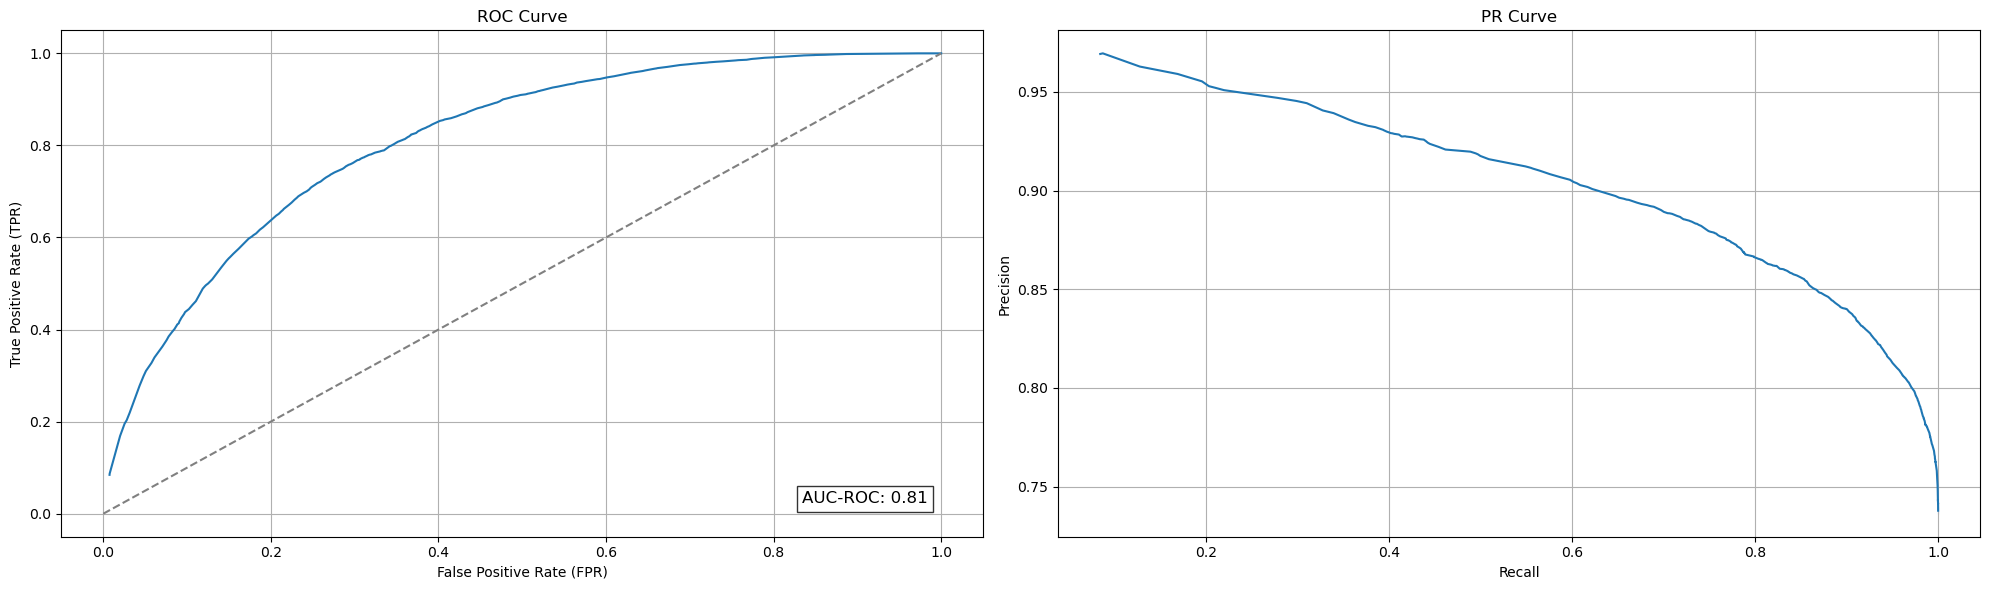

In [38]:
# Рассчитываем AUC ROC
auc_roc = calculate_auc_roc(model=cv_model,
                            test_data=test_df,
                            label_col="is_helpful")
pd_dataframe = calculate_metrics(model=cv_model,
                                 test_data=test_df,
                                 label_col="is_helpful")
plot_roc_pr_curves(pd_dataframe, auc_roc)

Определим вероятность -- границу разделения, при которой `Recall` не меньше 60%.

In [39]:
threshold_probability = pd_dataframe[pd_dataframe['TPR'] >= 0.60]['probability'].max()
print(f"Вероятность -- граница разделения, при которой TPR не меньше 60%: {threshold_probability:.2f}")

Вероятность -- граница разделения, при которой TPR не меньше 60%: 0.83


Рассчитаем метрики на тестовом датасете повторно, с учетом вычисленного `threshold` для вероятности.

In [40]:
cv_model.bestModel.stages[-1].setThresholds([1 - threshold_probability, 
                                             threshold_probability])
test_df_predictions = cv_model.transform(test_df)
metrics = evaluate_model(test_df_predictions, "is_helpful")
print(f"Metrics: {metrics}")

Матрица ошибок:
TP: 19454, FP: 2044
FN: 13020, TN: 9626
Всего записей: 44144
Metrics: {'precision': 0.9049213880360963, 'recall': 0.5990638664777976, 'f1': 0.7208923145334617, 'accuracy': 0.6587531714389272}


Не забываем завершать `Spark`-сессию.

In [41]:
spark.stop()